In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
import pickle

import warnings
warnings.filterwarnings("ignore")

In [2]:
# books = pd.read_csv("BX-Books.csv", sep=";", error_bad_lines=False, encoding="latin-1")
books = pd.read_csv("BX-Books.csv", sep=";", on_bad_lines='skip', encoding="latin-1")

In [3]:
users = pd.read_csv("BX-Users.csv", sep=";", on_bad_lines='skip', encoding="latin-1")

In [4]:
ratings = pd.read_csv("BX-Book-Ratings.csv", sep=";", on_bad_lines='skip', encoding="latin-1")

# Data Understanding

In [5]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [6]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [7]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [8]:
books.shape

(271360, 8)

In [9]:
users.shape

(278858, 3)

In [10]:
ratings.shape

(1149780, 3)

# Data Cleaning

In [11]:
books = books[["ISBN", "Book-Title", "Book-Author", "Year-Of-Publication", "Publisher"]]
books = books.rename(columns={
    "Book-Title":"title", 
    "Book-Author":"author", 
    "Year-Of-Publication":"year", 
    "Publisher":"publisher"})

In [12]:
users = users.rename(columns={
    "User-ID":"user_id", 
    "Location":"location", 
    "Age":"age"})

In [13]:
ratings = ratings.rename(columns={
    "User-ID":"user_id", 
    "Book-Rating":"rating"})

# Text Preprocessing

In [14]:
# OUTOFF 278858 USERS 105283 GAVE THE BOOK RATING

ratings["user_id"].value_counts().shape

(105283,)

In [15]:
# EXTRACTING THOSE USERS WHO HAVE ATLEAST RATED 200 BOOKS

x = ratings["user_id"].value_counts() > 200
x[x].shape     # 899 ARE THE USERS WHICH HAVE ATLEAST RATED 200 BOOKS AND x[x] EXTRACTS THEM
y = x[x].index
y

Index([ 11676, 198711, 153662,  98391,  35859, 212898, 278418,  76352, 110973,
       235105,
       ...
       260183,  73681,  44296, 155916,   9856, 274808,  28634,  59727, 268622,
       188951],
      dtype='int64', name='user_id', length=899)

In [16]:
# EXTRACTING 899 USERS FROM user_id  

ratings = ratings[ratings["user_id"].isin(y)]
ratings.shape     # 899 USERS RATED INALL 526356 BOOKS

(526356, 3)

In [17]:
book_rating = ratings.merge(books, on="ISBN")
book_rating.head()

,user_id,ISBN,rating,title,author,year,publisher
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books


In [18]:
book_rating.describe()

,user_id,rating
count,487671.000000,487671.000000
mean,142140.987975,1.943109
std,80640.283037,3.496579
min,254.000000,0.000000
25%,73394.000000,0.000000
50%,144531.000000,0.000000
75%,212898.000000,0.000000
max,278418.000000,10.000000


In [19]:
book_rating.sample(5)

,user_id,ISBN,rating,title,author,year,publisher
135329,77940,037309549X,0,"Lady Beware (Silhouette Special Edition, 549)",Gina Ferris,1989,Silhouette
47080,25409,1879102919,0,GIS for Everyone,David Davis,2000,ESRI Press
462838,259629,0440204194,0,Firefly Summer,Maeve Binchy,1989,Dell
247119,143253,0440214696,0,Making Love,Melanie Tem,1993,Dell Publishing Company
437848,245963,0385127723,0,Notes on Love and Courage,Hugh Prather,1993,Main Street Books


In [20]:
book_rating.shape

(487671, 7)

In [21]:
number_rating = book_rating.groupby("title")["rating"].count().reset_index()
number_rating.head()

,title,rating
0,A Light in the Storm: The Civil War Diary of ...,2
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,Beyond IBM: Leadership Marketing and Finance ...,1
4,Clifford Visita El Hospital (Clifford El Gran...,1


In [22]:
# FINDING NUMBER OF RATING FOR EACH BOOK

number_rating = number_rating.rename(columns={"rating":"number_of_rating"})
final_book_rating = book_rating.merge(number_rating, on="title")
final_book_rating.head()

,user_id,ISBN,rating,title,author,year,publisher,number_of_rating
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,82
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,7
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,1
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,1
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,13


In [23]:
final_book_rating.shape

(487671, 8)

In [24]:
# EXTRACTING THE BOOKS WHICH ARE ATLEAST GOT 50 RATINGS SO THAT THE MODEL WON'T DEVIATE FROM 1 or 2 BOOKS RATINGS

final_book_rating = final_book_rating[final_book_rating["number_of_rating"] >=50]
final_book_rating.sample(10)
final_book_rating.shape

(61853, 8)

In [25]:
final_book_rating.duplicated(["user_id", "title"]).sum()

2003

In [26]:
final_book_rating.drop_duplicates(["user_id","title"], inplace=True)
final_book_rating.shape

(59850, 8)

In [27]:
final_book_rating.head()

,user_id,ISBN,rating,title,author,year,publisher,number_of_rating
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,82
13,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,133
15,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,108
18,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,108
24,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,79


In [28]:
#TO GET UNIQUE SUGGESTIONS DURING SEARCH

unique = final_book_rating["title"].unique()
unique = pd.DataFrame(unique)
unique.head()

,0
0,Politically Correct Bedtime Stories: Modern Ta...
1,The Poisonwood Bible: A Novel
2,Bel Canto: A Novel
3,One for the Money (Stephanie Plum Novels (Pape...
4,The Secret Garden


In [29]:
users = pd.read_csv("users.csv")
users.head()

,user_id,user_name,email
0,1,Mohit,mohit07@gmail.com
1,2,Amitesh,amitesh03@gmail.com
2,3,Virat,virat18@gmail.com
3,4,Roman,roman01@gmail.com


In [30]:
import random

# Assuming users and book_rating are already loaded
num_interactions_per_user = 300  # Number of books to assign per user

# Create user interest table
user_interest_data = []

for user_id in users['user_id']:
    # Randomly select books for the user
    random_books = final_book_rating.sample(num_interactions_per_user)
    for _, book in random_books.iterrows():
        user_interest_data.append({
            'user_id': user_id,
            'ISBN': book['ISBN'],
            'rating': book['rating']  # Assign random ratings between 3 and 5
        })

# Convert to DataFrame
interaction_df = pd.DataFrame(user_interest_data)

In [31]:
interaction_df.sample(15)

,user_id,ISBN,rating
179,1,0670858692,10
276,1,0440213525,0
346,2,0425047075,6
1198,4,067976402X,0
911,4,0971880107,0
188,1,0425163407,0
1044,4,0385508042,0
665,3,0316777730,0
964,4,0440221471,0
273,1,0312201656,10


In [32]:
interaction_df.to_csv('book_interaction_df.csv', index=False)

In [33]:
interaction_df.shape

(1200, 3)

In [34]:
# book_pivot = final_book_rating.pivot_table(columns="user_id", index="title", values="rating")
# book_pivot.shape     # OUTOFF 899, 742 USERS BOOK RATINGS CAME > 50
# book_pivot.head()

In [35]:
book_pivot = interaction_df.pivot_table(columns="ISBN", index="user_id", values="rating")
book_pivot.shape
book_pivot.head()

ISBN,006001203X,0060090367,0060092572,0060096195,0060175400,0060179333,0060391626,0060392452,0060502258,0060512822,...,1558743669,1559029838,1565115430,1573225789,1573227331,1573229725,1586210661,184195425X,1878448900,8401422345
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,NaN,0.0,9.0,NaN,NaN,3.0,NaN,NaN,...,5.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,8.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,9.0,9.0,NaN,0.0
3,NaN,NaN,0.0,0.0,NaN,NaN,10.0,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,...,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,8.0,NaN


In [36]:
#REPLACE NAN VALUES WITH ZERO
book_pivot.fillna(0, inplace=True)
book_pivot.head()

ISBN,006001203X,0060090367,0060092572,0060096195,0060175400,0060179333,0060391626,0060392452,0060502258,0060512822,...,1558743669,1559029838,1565115430,1573225789,1573227331,1573229725,1586210661,184195425X,1878448900,8401422345
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,9.0,0.0,0.0,3.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0


In [37]:
# AS MANY ZERO VALUES ARE PRESENT IN book_pivot USING FOLLOWING LIBRARY book_sparse WILL ONLY CONSIDER NON-ZERO VALUES SO AS TO INCREASE COMPUTATION SPEED

from scipy.sparse import csr_matrix
book_sparse = csr_matrix(book_pivot)

In [38]:
book_sparse

<4x679 sparse matrix of type '<class 'numpy.float64'>'
	with 305 stored elements in Compressed Sparse Row format>

In [39]:
# Calculate sparsity
total_elements = book_sparse.shape[0] * book_sparse.shape[1]
nonzero_elements = book_sparse.nnz
sparsity = 1 - (nonzero_elements / total_elements)

print(f"Matrix dimensions: {book_sparse.shape}")
print(f"Non-zero elements: {nonzero_elements}")
print(f"Sparsity: {sparsity:.2%}")

Matrix dimensions: (4, 679)
Non-zero elements: 305
Sparsity: 88.77%


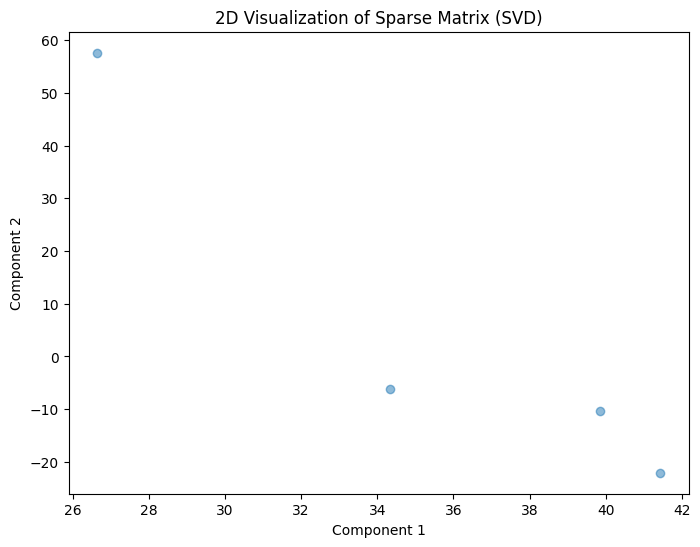

In [40]:
from sklearn.decomposition import TruncatedSVD

# Perform Truncated SVD
svd = TruncatedSVD(n_components=2)
reduced_matrix = svd.fit_transform(book_sparse)

# Scatter plot of the reduced dimensions
plt.figure(figsize=(8, 6))
plt.scatter(reduced_matrix[:, 0], reduced_matrix[:, 1], alpha=0.5)
plt.title('2D Visualization of Sparse Matrix (SVD)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

# Model Building

In [41]:
model = NearestNeighbors(algorithm="brute", metric="cosine")
model.fit(book_sparse)

NearestNeighbors(algorithm='brute', metric='cosine')

In [42]:
def recommend_books_for_user(user_id, user_interest_data, user_book_matrix, model, n_recommendations=5):
    # Check if the user exists in the interaction matrix
    if user_id not in user_book_matrix.index:
        return ["No recommendations available for this user."]
    
    # Get the user's vector
    user_vector = user_book_matrix.loc[user_id].values.reshape(1, -1)
    
    # Get the total number of users in the dataset
    total_users = user_book_matrix.shape[0]
    
    # Adjust n_neighbors to be at most total_users - 1
    n_neighbors = min(total_users - 1, n_recommendations + 1)
    
    # Find similar users
    distances, indices = model.kneighbors(user_vector, n_neighbors=n_neighbors)

    # Get similar users (excluding the logged-in user)
    similar_users = user_book_matrix.index[indices.flatten()[1:]]  # Skip the first user (itself)

    # Find books rated by similar users but not by the logged-in user
    similar_user_books = user_interest_data[
        user_interest_data['user_id'].isin(similar_users)
    ]
    logged_in_user_books = user_interest_data[
        user_interest_data['user_id'] == user_id
    ]['ISBN']

    # Recommend books not already rated by the logged-in user
    recommendations = similar_user_books[
        ~similar_user_books['ISBN'].isin(logged_in_user_books)
    ].drop_duplicates(subset='ISBN').head(n_recommendations)

    # Return book titles
    return recommendations.merge(book_rating[['ISBN', 'title']].drop_duplicates(), on='ISBN', how='left')['title'].tolist()


In [54]:
logged_in_user_id = 1  # Example: User ID of Mohit
recommendations = recommend_books_for_user(
    user_id=logged_in_user_id,
    user_interest_data=interaction_df,
    user_book_matrix=book_pivot,
    model=model,
    n_recommendations=25
)
print(f"Recommended books for user {logged_in_user_id}: {recommendations}")

Recommended books for user 1: ['H Is for Homicide (Kinsey Millhone Mysteries (Paperback))', 'Patriot Games (Jack Ryan Novels)', 'Violin', "The Pilot's Wife : A Novel", 'The Terminal Man', 'The Dead Zone', 'All Around the Town', 'Little Altars Everywhere: A Novel', 'Mind Prey', 'Tales of a Fourth Grade Nothing', 'The Stone Diaries', 'A Thin Dark Line (Mysteries &amp; Horror)', "From Potter's Field", "Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson", 'Dreamcatcher', 'Harry Potter and the Goblet of Fire (Book 4)', 'Wanderlust', 'The Gift', 'Tara Road', 'Fingersmith', 'Oryx and Crake', 'Silent Witness', 'The Queen of the Damned (Vampire Chronicles (Paperback))', 'Homeport', 'One True Thing']


In [44]:
# distances, suggestions = model.kneighbors(book_pivot.iloc[237,:].values.reshape(1,-1), n_neighbors=6)

In [45]:
# def recommend_book(book_name):
#     book_id = np.where(book_pivot.index==book_name)[0][0]
#     distances, suggestions = model.kneighbors(book_pivot.iloc[book_id,:].values.reshape(1,-1), n_neighbors=6)
    
#     for i in range(len(suggestions)):
#         print(book_pivot.index[suggestions[i]][1:])

In [46]:
# recommend_book("The Vampire Lestat (Vampire Chronicles, Book II)")

In [47]:
# unique.sample(10)

In [48]:
pickle.dump(book_pivot, open("book_pivot.pkl", "wb"))

In [49]:
pickle.dump(model, open("book_recc_model.pkl", "wb"))

In [50]:
# pickle.dump(book_sparse, open("book_sparse.pkl", "wb"))

In [51]:
# pickle.dump(unique, open("unique.pkl", "wb"))